In [1]:
import os
os.chdir("../dgl_ptm/")

import sys
import dgl_ptm

os.environ["DGLBACKEND"] = "pytorch"
import torch

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
model = dgl_ptm.SEIRModel(model_identifier='seir_test')
seed = 42

In [3]:
# from dgl_ptm.environment import grid_creation

# kwargs = {
#     "method": "custom_import",
#     "path": "ghana_grid.npy",
#     "properties": {"population": 0}
# }

# grid = grid_creation.grid_creation(**kwargs)
# plt.imshow(grid.get_slice("population"), norm=LogNorm(), cmap="viridis")
# plt.gca().invert_yaxis()
# plt.show()

In [4]:
model.set_model_parameters(**{
    'number_agents': 100,
    'seed':seed,
    'spatial': True,
    'spatial_creation_args':{
        "method": "custom_import",
        "path": "ghana_grid.npy",
        "properties": {"population": 0}
    },
    'spatial_assignment_args':{'method':"property",'property':"population"},
    'initial_graph_type': 'barabasi-albert',
    'initial_graph_args': {'seed': seed, 'new_node_edges':5},
    'device': 'cpu',
    'step_target':5,
    'steering_parameters': {
        'npath':'./agent_data.zarr',
        'epath':'./edge_data',
        'ndata':[[],['initial_only',[]]],
        'edata':None,
        'mode':'w',
        'infection_probability':0.3,
        'incubation_period':5,
        'infections_period':3,
        'initial_infected_proportion':0.03,
        'step_type':'seir'
    }
})

{'npath': './agent_data.zarr', 'epath': './edge_data', 'ndata': [[], ['initial_only', []]], 'edata': None, 'mode': 'w', 'infection_probability': 0.3, 'incubation_period': 5, 'infections_period': 3, 'initial_infected_proportion': 0.03, 'step_type': 'seir', 'data_collection_period': 1, 'data_collection_list': None}

npath='./agent_data.zarr' epath='./edge_data' ndata=[[], ['initial_only', []]] edata=None mode='w' infection_probability=0.3 incubation_period=5 infections_period=3 initial_infected_proportion=0.03 step_type='seir' data_collection_period=1 data_collection_list=None


In [5]:
model.initialize_model()

print(model.config)
print(model.config.steering_parameters.global_theta)

Model torch seed set to 42
Using seed 42 for network creation with 5 edges requested.
{'population': 0}
torch.Size([75, 75, 1])
tensor([ 9., 16., 46., 44.,  8.,  4., 34., 42., 47., 13., 11., 48., 27., 16.,
        48., 44., 53., 33., 31., 30., 39., 36., 56., 47., 37., 15., 31., 53.,
        41., 12.,  9., 17., 56., 10., 58., 66., 23., 39., 48., 17., 49., 42.,
        67., 52., 38., 48., 49., 32., 22., 35., 10., 62., 14., 39.,  3., 59.,
        14., 47., 38.,  9., 30.,  9., 13., 47., 50., 39., 46., 46., 27., 29.,
         6., 36., 48., 23., 26.,  9., 32., 25., 22., 21., 68., 52., 26., 37.,
        33., 49., 17., 38., 32., 24., 44., 12., 52., 62., 37.,  7.,  5., 31.,
         9., 47.])
tensor([ 5.,  5.,  7.,  4., 23., 21., 62., 56.,  5.,  8.,  9., 18., 43., 47.,
        18., 26.,  5., 31., 27., 20.,  5., 30., 15., 15.,  3.,  4., 57.,  8.,
        13.,  8., 13., 12., 11., 16., 26., 25., 44.,  3., 15., 20., 57.,  7.,
        19., 14., 67., 43., 18.,  6., 29., 25., 32., 20.,  6., 26., 22., 

KeyError: 'homophily_parameter'

In [38]:
model.graph

Graph(num_nodes=20, num_edges=150,
      ndata_schemes={'x': Scheme(shape=(), dtype=torch.float32), 'y': Scheme(shape=(), dtype=torch.float32), 'wealth': Scheme(shape=(), dtype=torch.float32), 'alpha': Scheme(shape=(), dtype=torch.float32), 'theta': Scheme(shape=(), dtype=torch.float32), 'sensitivity': Scheme(shape=(), dtype=torch.float32), 'lambda': Scheme(shape=(), dtype=torch.float32), 'sigma': Scheme(shape=(), dtype=torch.float32), 'tech_index': Scheme(shape=(), dtype=torch.float32), 'income': Scheme(shape=(), dtype=torch.float32), 'a_table': Scheme(shape=(2, 3), dtype=torch.float32), 'wealth_consumption': Scheme(shape=(), dtype=torch.float32), 'i_a': Scheme(shape=(), dtype=torch.float32), 'm': Scheme(shape=(), dtype=torch.float32), 'net_trade': Scheme(shape=(), dtype=torch.float32), 'degree': Scheme(shape=(), dtype=torch.int64), 'weighted_degree': Scheme(shape=(), dtype=torch.float32), 'zeros': Scheme(shape=(), dtype=torch.float32), 'ones': Scheme(shape=(), dtype=torch.float32)}
 

In [39]:
import networkx as nx

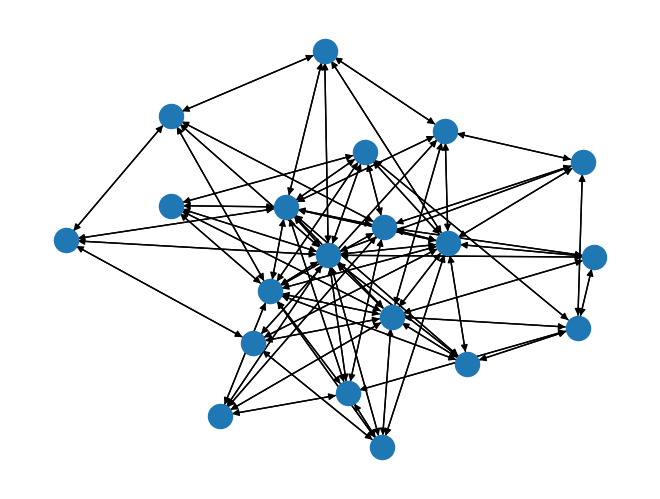

In [42]:
nx.draw(model.graph.to_networkx())

In [5]:
model.run()

#tensor([14,  6, 35, 22,  0, 21,  9, 62, 52,  2,  7, 12, 46,  8,  7, 12, 52, 67,
#        79, 52, 67, 21, 74, 67, 64])

performing step 0 of 5
Agent graph storage type: torch.int32
Income:tensor([2.5049, 1.9366, 2.0982, 1.3181, 0.6590])
ATTENTION: No edge data collection requested for this simulation!
performing step 1 of 5
k before:tensor([8.1439, 6.4188, 7.5356, 3.5108, 1.7470])
Total In:tensor([4.3382, 1.9064, 2.0338, 1.8727, 0.2067])
Disposable Wealth:tensor([3.2576, 1.2838, 3.7678, 0.7022, 0.1747])
Net Trade:tensor([ 1.0806,  0.6226, -1.7340,  1.1705,  0.0320])
k after:tensor([9.2246, 7.0415, 5.8016, 4.6813, 1.7790])
Income:tensor([2.7314, 2.0651, 1.8958, 1.6929, 1.3841])
performing step 2 of 5
k before:tensor([9.1431, 7.1961, 6.2994, 5.4392, 3.4278])
Total In:tensor([2.6647, 1.7981, 1.3765, 1.5464, 0.6903])
Disposable Wealth:tensor([3.6573, 1.4392, 3.1497, 1.0878, 0.3428])
Net Trade:tensor([-0.9925,  0.3589, -1.7732,  0.4585,  0.3476])
k after:tensor([8.1506, 7.5550, 4.5262, 5.8977, 3.7753])
Income:tensor([2.5482, 2.1292, 1.7392, 1.8327, 1.7346])
performing step 3 of 5
k before:tensor([8.3299, 7.5

In [ ]:
import zarr
import os
zarr_file_one = zarr.open('/Users/victoria/Documents/Scripts/Python/DGL-PTM/Sensitivity_Analysis/data_mode_A/agent_data.zarr', mode='r')
zarr_file_two = zarr.open('/Users/victoria/Documents/Scripts/Python/DGL-PTM/Sensitivity_Analysis/data_mode_B/agent_data.zarr', mode='r')
zarr_file_three = zarr.open('/Users/victoria/Documents/Scripts/Python/DGL-PTM/Sensitivity_Analysis/data_mode_B/agent_data_initial.zarr', mode='r')
zarr_file_four = zarr.open('/Users/victoria/Documents/Scripts/Python/DGL-PTM/Sensitivity_Analysis/SA_test/agent_data.zarr', mode='r')

#print(zarr_file_one.tree())
#print(zarr_file_two.tree())
#print(zarr_file_three.tree())

#attributes=os.listdir('/Users/victoria/Documents/Scripts/Python/DGL-PTM/Sensitivity_Analysis/test_SA/agent_data.zarr')
#attributes = [item for item in attributes if item not in ['.zattrs','.zmetadata','.zgroup']]
#attributes = {key: None for key in attributes}
#print(attributes)
#print(zarr_file_one['wealth'][0:2])
#print(zarr_file_two['wealth'][0:2])

#print(zarr_file_one['alpha'][0:2])
#print(zarr_file_two['alpha'][0:2])

#format: zarr_file['property'][agent(s),timestep(s)]
print(zarr_file_four['wealth'][0:20,0])

#Unnecessary:'a_table','m','tec','gamma','cost','zeros','ones', 'total_weight', "disposable_wealth"
#One-Time: 'alpha',"lambda","sigma","sensitivity"
#Every-Time: 'degree','i_a','income','net_trade', 'tech_index','theta', 'wealth', 'wealth_consumption','weighted_degree'


In [ ]:
ndata = ['all']
ndata = ['all_except',['a_table','m','tec','gamma','cost','zeros','ones', 'total_weight', "disposable_wealth"]]
ndata = [['all_except',['a_table','m','tec','gamma','cost','zeros','ones', 'total_weight', "disposable_wealth"]], ["initial_only",['alpha',"lambda","sigma","sensitivity"]]]
ndata = [['degree','i_a','income','net_trade', 'tech_index','theta', 'wealth', 'wealth_consumption','weighted_degree'], ["initial_only",['alpha',"lambda","sigma","sensitivity"]]]

timestep = 10

if ndata == ['all']:
    ndata = list(attributes.keys())
elif ndata[0] == 'all_except':
    ndata = list(attributes.keys() - ndata[1])
elif sum(1 for item in ndata if isinstance(item, list)) > 1:
    ndata_list = ndata
    initial_only=[]
    for specification in ndata_list:
        if specification == ['all']:
            raise ValueError('Use of "all" is not compatible with multiple data collection specification lists.')
        elif specification[0] == 'all_except':
            ndata = list(attributes.keys() - specification[1])
        elif specification[0] == 'initial_only':
            if timestep == 0:
                initial_only = specification[1]
        else:
            ndata = specification
    ndata=ndata+initial_only


print(ndata)
